# Vendor Risk Assessment & Procurement Governance Dashboard
## Business Scenario

### You are acting as a Vendor Risk Analyst / GRC Analyst / Procurement Risk Analyst.

#### Leadership wants to evaluate supplier performance and identify:

- high-risk vendors
-  late or delayed deliveries
- defective product risk
- compliance failures
- cancelled order exposure
- pricing/negotiation effectiveness
- supplier concentration risk
- vendor governance control failures

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)

#load data
df = pd.read_csv(r"C:\Users\Amira\Downloads\Project5_vendor_risk\Procurement KPI Analysis Dataset.csv")

print(df.shape)
df.head()

(777, 11)


,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             777 non-null    str    
 1   Supplier          777 non-null    str    
 2   Order_Date        777 non-null    str    
 3   Delivery_Date     690 non-null    str    
 4   Item_Category     777 non-null    str    
 5   Order_Status      777 non-null    str    
 6   Quantity          777 non-null    int64  
 7   Unit_Price        777 non-null    float64
 8   Negotiated_Price  777 non-null    float64
 9   Defective_Units   641 non-null    float64
 10  Compliance        777 non-null    str    
dtypes: float64(3), int64(1), str(7)
memory usage: 66.9 KB


In [3]:
#standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.head()

,po_id,supplier,order_date,delivery_date,item_category,order_status,quantity,unit_price,negotiated_price,defective_units,compliance
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


In [4]:
#conver date
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

df["delivery_date"] = pd.to_datetime(
    df["delivery_date"],
    errors="coerce"
)

#create procurment metrics
df["delivery_days"] = (
    df["delivery_date"] - df["order_date"]
).dt.days

df["gross_order_value"] = (
    df["quantity"] * df["unit_price"]
)

df["negotiated_order_value"] = (
    df["quantity"] * df["negotiated_price"]
)

df["cost_savings"] = (
    df["gross_order_value"] - df["negotiated_order_value"]
)

df["cost_savings_rate"] = (
    df["cost_savings"] / df["gross_order_value"]
) * 100

#defect rates
df["defective_units"] = df["defective_units"].fillna(0)

df["defect_rate"] = (
    df["defective_units"] / df["quantity"]
) * 100

In [5]:
##Vendor risk flags

#late flag
delivery_threshold = df["delivery_days"].quantile(0.75)

df["late_delivery_flag"] = (
    df["delivery_days"] > delivery_threshold
)

print("Late Delivery Threshold:", delivery_threshold)
print("Late Deliveries:", df["late_delivery_flag"].sum())

Late Delivery Threshold: 16.0
Late Deliveries: 140


In [6]:
#high defect flag
defect_threshold = df["defect_rate"].quantile(0.75)

df["high_defect_flag"] = (
    df["defect_rate"] > defect_threshold
)

print("High Defect Threshold:", round(defect_threshold, 2))
print("High Defect Orders:", df["high_defect_flag"].sum())

High Defect Threshold: 9.8
High Defect Orders: 194


In [7]:
#compliance flag
df["compliance_failure_flag"] = (
    df["compliance"].str.lower() == "no"
)

df["compliance_failure_flag"].sum()

np.int64(137)

In [8]:
#cancelled flag
df["cancelled_order_flag"] = (
    df["order_status"].str.lower() == "cancelled"
)

df["cancelled_order_flag"].sum()

np.int64(63)

In [9]:
#low savings flag
savings_threshold = df["cost_savings_rate"].quantile(0.25)

df["low_savings_flag"] = (
    df["cost_savings_rate"] < savings_threshold
)

print("Low Savings Threshold:", round(savings_threshold, 2))
print("Low Savings Orders:", df["low_savings_flag"].sum())

Low Savings Threshold: 4.28
Low Savings Orders: 194


In [10]:
##Risk scoring
df["vendor_risk_score"] = 0

df.loc[df["late_delivery_flag"], "vendor_risk_score"] += 2
df.loc[df["high_defect_flag"], "vendor_risk_score"] += 3
df.loc[df["compliance_failure_flag"], "vendor_risk_score"] += 4
df.loc[df["cancelled_order_flag"], "vendor_risk_score"] += 3
df.loc[df["low_savings_flag"], "vendor_risk_score"] += 1

#risk level
def vendor_risk_level(score):

    if score <= 2:
        return "Low"

    elif score <= 5:
        return "Medium"

    elif score <= 8:
        return "High"

    else:
        return "Critical"


df["vendor_risk_level"] = (
    df["vendor_risk_score"]
    .apply(vendor_risk_level)
)

#review results
df[[
    "po_id",
    "supplier",
    "item_category",
    "order_status",
    "delivery_days",
    "defect_rate",
    "compliance",
    "cost_savings_rate",
    "vendor_risk_score",
    "vendor_risk_level"
]].head(10)

,po_id,supplier,item_category,order_status,delivery_days,defect_rate,compliance,cost_savings_rate,vendor_risk_score,vendor_risk_level
0,PO-00001,Alpha_Inc,Office Supplies,Cancelled,8.0,0.000000,Yes,11.525087,3,Medium
1,PO-00002,Delta_Logistics,Office Supplies,Delivered,10.0,15.573227,Yes,5.035605,3,Medium
2,PO-00003,Gamma_Co,MRO,Delivered,20.0,4.505495,Yes,3.402785,3,Medium
3,PO-00004,Beta_Supplies,Packaging,Delivered,19.0,8.333333,Yes,4.336505,2,Low
4,PO-00005,Delta_Logistics,Raw Materials,Delivered,12.0,14.491525,No,5.525207,7,High
5,PO-00006,Epsilon_Group,MRO,Delivered,12.0,3.406114,Yes,8.149111,0,Low
6,PO-00007,Gamma_Co,MRO,Delivered,11.0,5.411499,No,6.910648,4,Medium
7,PO-00008,Alpha_Inc,MRO,Delivered,14.0,2.010969,Yes,11.237476,0,Low
8,PO-00009,Gamma_Co,Raw Materials,Partially Delivered,4.0,5.272512,Yes,9.196449,0,Low
9,PO-00010,Gamma_Co,Raw Materials,Pending,12.0,4.678363,Yes,8.676987,0,Low


In [11]:
##Supplier risk summary
supplier_summary = (
    df.groupby("supplier")
      .agg(
          total_orders=("po_id", "count"),
          total_spend=("negotiated_order_value", "sum"),
          avg_delivery_days=("delivery_days", "mean"),
          late_delivery_rate=("late_delivery_flag", "mean"),
          avg_defect_rate=("defect_rate", "mean"),
          compliance_failure_rate=("compliance_failure_flag", "mean"),
          cancelled_order_rate=("cancelled_order_flag", "mean"),
          avg_cost_savings_rate=("cost_savings_rate", "mean"),
          avg_vendor_risk_score=("vendor_risk_score", "mean")
      )
      .reset_index()
)

supplier_summary["late_delivery_rate"] *= 100
supplier_summary["compliance_failure_rate"] *= 100
supplier_summary["cancelled_order_rate"] *= 100

supplier_summary.head()

,supplier,total_orders,total_spend,avg_delivery_days,late_delivery_rate,avg_defect_rate,compliance_failure_rate,cancelled_order_rate,avg_cost_savings_rate,avg_vendor_risk_score
0,Alpha_Inc,141,7839712.25,10.606838,14.893617,1.890548,6.382979,9.219858,8.210459,1.113475
1,Beta_Supplies,156,9858665.90,11.272727,19.230769,8.272327,24.358974,8.974359,7.827699,3.185897
2,Delta_Logistics,171,9236240.47,10.854305,21.052632,10.866574,39.181287,9.356725,7.811977,4.684211
3,Epsilon_Group,166,9851156.06,10.865772,19.277108,2.606269,1.807229,8.433735,8.040521,0.957831
4,Gamma_Co,143,8587921.71,10.192308,14.685315,4.497537,13.986014,4.195804,7.984856,1.251748


In [12]:
#risk level
def supplier_risk_level(score):

    if score <= 2:
        return "Low"

    elif score <= 5:
        return "Medium"

    elif score <= 8:
        return "High"

    else:
        return "Critical"


supplier_summary["supplier_risk_level"] = (
    supplier_summary["avg_vendor_risk_score"]
    .apply(supplier_risk_level)
)

supplier_summary.sort_values(
    "avg_vendor_risk_score",
    ascending=False
)

,supplier,total_orders,total_spend,avg_delivery_days,late_delivery_rate,avg_defect_rate,compliance_failure_rate,cancelled_order_rate,avg_cost_savings_rate,avg_vendor_risk_score,supplier_risk_level
2,Delta_Logistics,171,9236240.47,10.854305,21.052632,10.866574,39.181287,9.356725,7.811977,4.684211,Medium
1,Beta_Supplies,156,9858665.90,11.272727,19.230769,8.272327,24.358974,8.974359,7.827699,3.185897,Medium
4,Gamma_Co,143,8587921.71,10.192308,14.685315,4.497537,13.986014,4.195804,7.984856,1.251748,Low
0,Alpha_Inc,141,7839712.25,10.606838,14.893617,1.890548,6.382979,9.219858,8.210459,1.113475,Low
3,Epsilon_Group,166,9851156.06,10.865772,19.277108,2.606269,1.807229,8.433735,8.040521,0.957831,Low


In [13]:
##Governance control testing

#control rules
df["ctrl_supplier_present"] = df["supplier"].notna()

df["ctrl_order_dates_present"] = (
    df["order_date"].notna() &
    df["delivery_date"].notna()
)

df["ctrl_positive_quantity"] = (
    df["quantity"] > 0
)

df["ctrl_prices_present"] = (
    df["unit_price"].notna() &
    df["negotiated_price"].notna()
)

df["ctrl_compliance_present"] = (
    df["compliance"].notna()
)

df["ctrl_delivery_time_valid"] = (
    df["delivery_days"].notna() &
    (df["delivery_days"] >= 0)
)

#auto control testing summary
control_tests = {
    "CTRL-001 Supplier Present": "ctrl_supplier_present",
    "CTRL-002 Order and Delivery Dates Present": "ctrl_order_dates_present",
    "CTRL-003 Positive Quantity": "ctrl_positive_quantity",
    "CTRL-004 Price Fields Present": "ctrl_prices_present",
    "CTRL-005 Compliance Status Present": "ctrl_compliance_present",
    "CTRL-006 Valid Delivery Timeline": "ctrl_delivery_time_valid"
}

control_results = []

for control_name, rule_col in control_tests.items():

    total_tested = len(df)
    passed = int(df[rule_col].sum())
    failed = total_tested - passed
    pass_rate = round((passed / total_tested) * 100, 2)

    if pass_rate >= 95:
        effectiveness = "Effective"
    elif pass_rate >= 85:
        effectiveness = "Needs Monitoring"
    else:
        effectiveness = "Ineffective"

    control_results.append({
        "Control": control_name,
        "Total Tested": total_tested,
        "Passed": passed,
        "Failed": failed,
        "Pass Rate %": pass_rate,
        "Effectiveness": effectiveness
    })

control_summary_df = pd.DataFrame(control_results)

control_summary_df

,Control,Total Tested,Passed,Failed,Pass Rate %,Effectiveness
0,CTRL-001 Supplier Present,777,777,0,100.00,Effective
1,CTRL-002 Order and Delivery Dates Present,777,690,87,88.80,Needs Monitoring
2,CTRL-003 Positive Quantity,777,777,0,100.00,Effective
3,CTRL-004 Price Fields Present,777,777,0,100.00,Effective
4,CTRL-005 Compliance Status Present,777,777,0,100.00,Effective
5,CTRL-006 Valid Delivery Timeline,777,689,88,88.67,Needs Monitoring


In [14]:
##======KPIs======##

#kpi calcs
total_pos = len(df)

total_suppliers = df["supplier"].nunique()

total_spend = round(
    df["negotiated_order_value"].sum(),
    2
)

avg_delivery_days = round(
    df["delivery_days"].mean(),
    2
)

late_orders = int(
    df["late_delivery_flag"].sum()
)

compliance_failures = int(
    df["compliance_failure_flag"].sum()
)

cancelled_orders = int(
    df["cancelled_order_flag"].sum()
)

high_risk_orders = len(
    df[df["vendor_risk_level"] == "High"]
)

critical_risk_orders = len(
    df[df["vendor_risk_level"] == "Critical"]
)

print("Total POs:", total_pos)
print("Total Suppliers:", total_suppliers)
print("Total Spend:", total_spend)
print("Average Delivery Days:", avg_delivery_days)
print("Late Orders:", late_orders)
print("Compliance Failures:", compliance_failures)
print("Cancelled Orders:", cancelled_orders)
print("High Risk Orders:", high_risk_orders)
print("Critical Risk Orders:", critical_risk_orders)

Total POs: 777
Total Suppliers: 5
Total Spend: 45373696.39
Average Delivery Days: 10.78
Late Orders: 140
Compliance Failures: 137
Cancelled Orders: 63
High Risk Orders: 71
Critical Risk Orders: 21


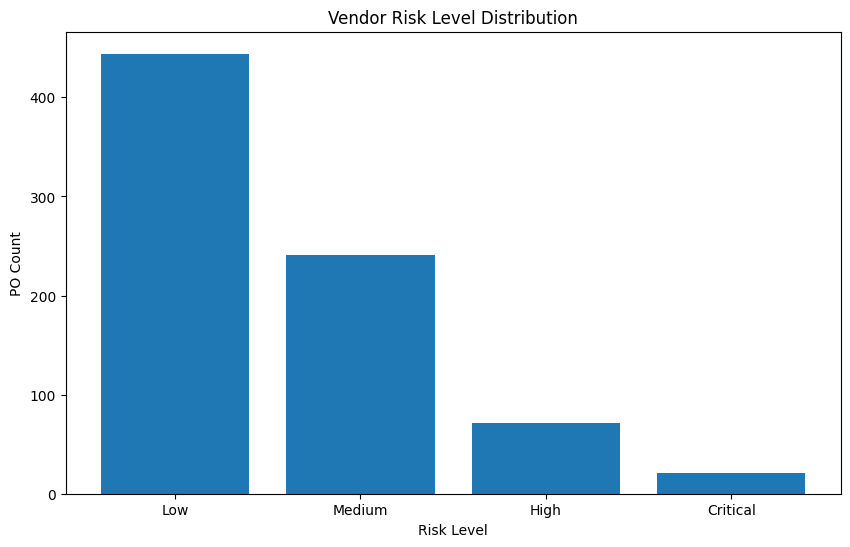

In [15]:
#risk level dist
risk_counts = (
    df["vendor_risk_level"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title("Vendor Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("PO Count")

plt.show()

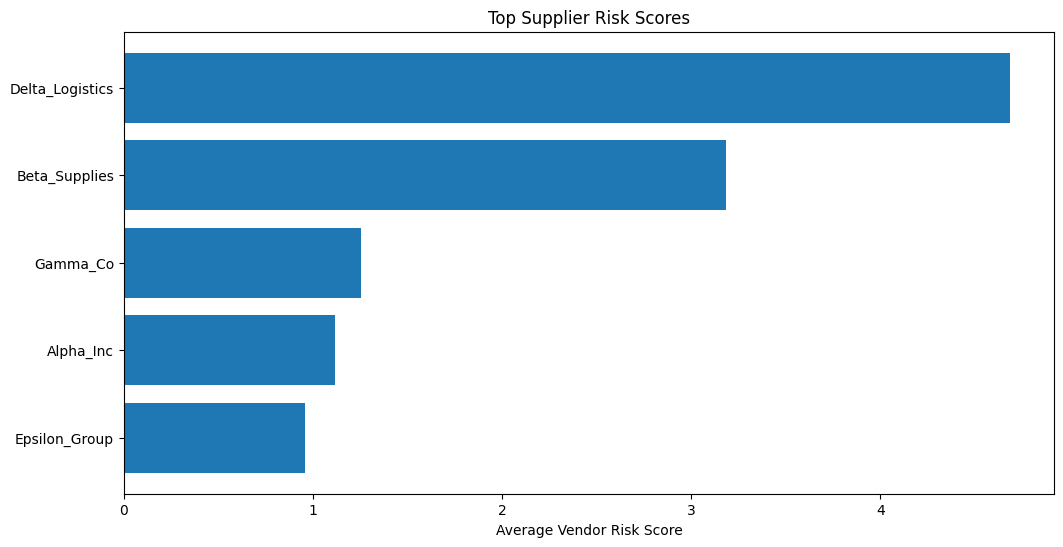

In [16]:
#risk ranking
top_supplier_risk = (
    supplier_summary
    .sort_values("avg_vendor_risk_score", ascending=True)
    .tail(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_supplier_risk["supplier"],
    top_supplier_risk["avg_vendor_risk_score"]
)

plt.title("Top Supplier Risk Scores")
plt.xlabel("Average Vendor Risk Score")

plt.show()

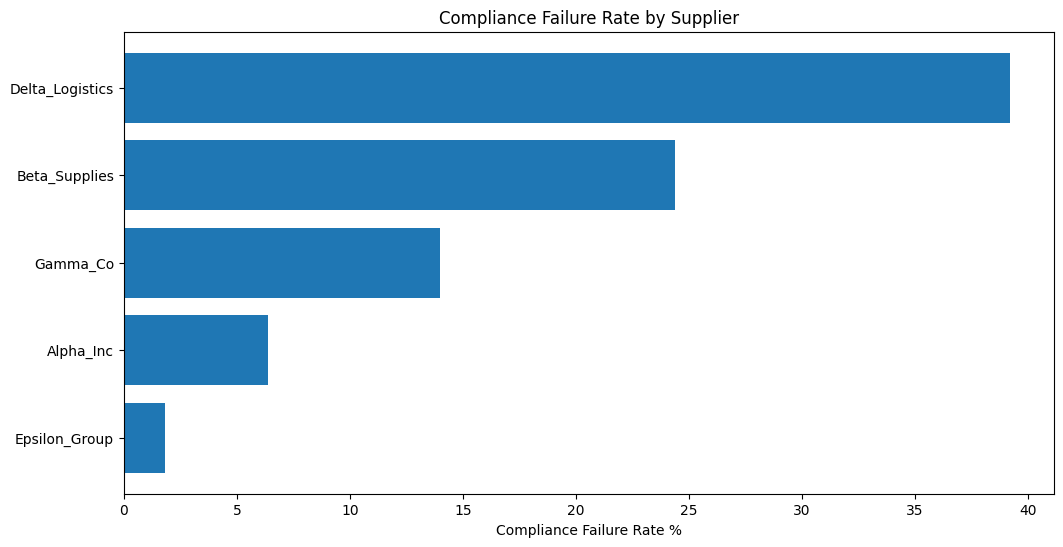

In [17]:
#compliance failure rate
compliance_by_supplier = (
    supplier_summary
    .sort_values("compliance_failure_rate", ascending=True)
    .tail(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    compliance_by_supplier["supplier"],
    compliance_by_supplier["compliance_failure_rate"]
)

plt.title("Compliance Failure Rate by Supplier")
plt.xlabel("Compliance Failure Rate %")

plt.show()

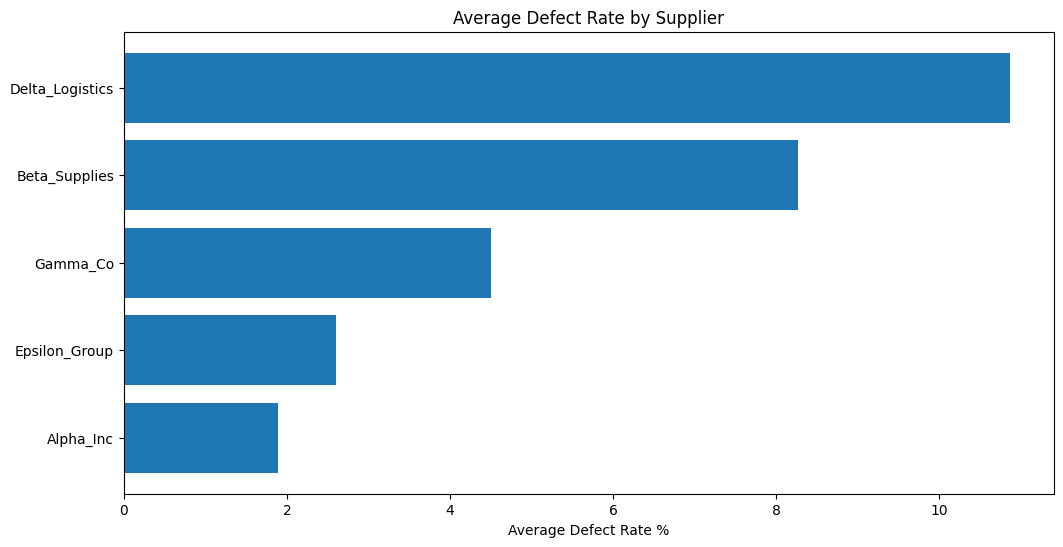

In [18]:
#defect rate
defect_by_supplier = (
    supplier_summary
    .sort_values("avg_defect_rate", ascending=True)
    .tail(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    defect_by_supplier["supplier"],
    defect_by_supplier["avg_defect_rate"]
)

plt.title("Average Defect Rate by Supplier")
plt.xlabel("Average Defect Rate %")

plt.show()

## Vendor Risk Assessment Framework

This project evaluates procurement and supplier performance data from a vendor risk management perspective.

The analysis transforms purchase order data into a supplier-level governance framework by calculating delivery performance, defect rates, compliance failures, cancelled order exposure, negotiated savings, and vendor risk scores.

Each purchase order is evaluated using vendor risk flags, including late delivery, high defect rate, compliance failure, cancelled order status, and low negotiated savings. These indicators are then combined into a vendor risk score and classified into Low, Medium, High, or Critical risk categories.

The purpose of this framework is to identify high-risk suppliers, monitor third-party performance, evaluate procurement governance controls, and support vendor management decisions.

---

In [19]:
##Vendor risk register

#assign risk owner
def assign_vendor_owner(row):

    if row["compliance_failure_rate"] > 25:
        return "Compliance Management"

    elif row["avg_defect_rate"] > supplier_summary["avg_defect_rate"].quantile(0.75):
        return "Supplier Quality Team"

    elif row["late_delivery_rate"] > supplier_summary["late_delivery_rate"].quantile(0.75):
        return "Procurement Operations"

    elif row["cancelled_order_rate"] > supplier_summary["cancelled_order_rate"].quantile(0.75):
        return "Vendor Management"

    elif row["total_spend"] > supplier_summary["total_spend"].quantile(0.75):
        return "Strategic Sourcing"

    else:
        return "Procurement Governance"


supplier_summary["risk_owner"] = (
    supplier_summary.apply(assign_vendor_owner, axis=1)
)

#vendor risk status
def assign_vendor_status(row):

    if row["supplier_risk_level"] == "Critical":
        return "Escalated"

    elif row["supplier_risk_level"] == "High":
        return "Remediation Required"

    elif row["supplier_risk_level"] == "Medium":
        return "Under Review"

    else:
        return "Monitoring"


supplier_summary["vendor_status"] = (
    supplier_summary.apply(assign_vendor_status, axis=1)
)

In [20]:
#remediation priority
def assign_remediation_priority(row):

    if row["supplier_risk_level"] == "Critical":
        return "Critical"

    elif row["compliance_failure_rate"] > 25:
        return "High"

    elif row["avg_defect_rate"] > supplier_summary["avg_defect_rate"].quantile(0.75):
        return "High"

    elif row["late_delivery_rate"] > supplier_summary["late_delivery_rate"].quantile(0.75):
        return "Medium"

    elif row["cancelled_order_rate"] > supplier_summary["cancelled_order_rate"].quantile(0.75):
        return "Medium"

    else:
        return "Low"


supplier_summary["remediation_priority"] = (
    supplier_summary.apply(assign_remediation_priority, axis=1)
)

#assign action
def assign_vendor_remediation(row):

    if row["supplier_risk_level"] == "Critical":
        return "Immediate vendor escalation and corrective action plan required"

    elif row["compliance_failure_rate"] > 25:
        return "Perform supplier compliance review and require remediation evidence"

    elif row["avg_defect_rate"] > supplier_summary["avg_defect_rate"].quantile(0.75):
        return "Initiate supplier quality review and defect reduction plan"

    elif row["late_delivery_rate"] > supplier_summary["late_delivery_rate"].quantile(0.75):
        return "Review delivery performance and establish corrective delivery SLA"

    elif row["cancelled_order_rate"] > supplier_summary["cancelled_order_rate"].quantile(0.75):
        return "Review cancellation drivers and supplier fulfillment reliability"

    elif row["avg_cost_savings_rate"] < supplier_summary["avg_cost_savings_rate"].quantile(0.25):
        return "Review pricing and negotiation strategy for supplier"

    else:
        return "Continue standard vendor monitoring"


supplier_summary["remediation_action"] = (
    supplier_summary.apply(assign_vendor_remediation, axis=1)
)

In [21]:
#review timeline
def assign_review_days(priority):

    if priority == "Critical":
        return 7

    elif priority == "High":
        return 14

    elif priority == "Medium":
        return 30

    else:
        return 60


supplier_summary["review_days"] = (
    supplier_summary["remediation_priority"]
    .apply(assign_review_days)
)

#review deadline
supplier_latest_dates = (
    df.groupby("supplier")["delivery_date"]
      .max()
      .reset_index()
      .rename(columns={"delivery_date": "latest_delivery_date"})
)

supplier_summary = supplier_summary.merge(
    supplier_latest_dates,
    on="supplier",
    how="left"
)

supplier_summary["review_due_date"] = (
    supplier_summary["latest_delivery_date"] +
    pd.to_timedelta(
        supplier_summary["review_days"],
        unit="D"
    )
)

#overdue review flag
supplier_summary["review_overdue_flag"] = (
    supplier_summary["review_due_date"] < pd.Timestamp.today()
)

In [22]:
#register
vendor_risk_register = supplier_summary[[
    "supplier",
    "total_orders",
    "total_spend",
    "avg_delivery_days",
    "late_delivery_rate",
    "avg_defect_rate",
    "compliance_failure_rate",
    "cancelled_order_rate",
    "avg_cost_savings_rate",
    "avg_vendor_risk_score",
    "supplier_risk_level",
    "risk_owner",
    "vendor_status",
    "remediation_priority",
    "remediation_action",
    "latest_delivery_date",
    "review_due_date",
    "review_overdue_flag"
]].copy()

vendor_risk_register = vendor_risk_register.sort_values(
    "avg_vendor_risk_score",
    ascending=False
)

vendor_risk_register.head()

,supplier,total_orders,total_spend,avg_delivery_days,late_delivery_rate,avg_defect_rate,compliance_failure_rate,cancelled_order_rate,avg_cost_savings_rate,avg_vendor_risk_score,supplier_risk_level,risk_owner,vendor_status,remediation_priority,remediation_action,latest_delivery_date,review_due_date,review_overdue_flag
2,Delta_Logistics,171,9236240.47,10.854305,21.052632,10.866574,39.181287,9.356725,7.811977,4.684211,Medium,Compliance Management,Under Review,High,Perform supplier compliance review and require...,2024-01-04,2024-01-18,True
1,Beta_Supplies,156,9858665.90,11.272727,19.230769,8.272327,24.358974,8.974359,7.827699,3.185897,Medium,Strategic Sourcing,Under Review,Low,Continue standard vendor monitoring,2024-01-11,2024-03-11,True
4,Gamma_Co,143,8587921.71,10.192308,14.685315,4.497537,13.986014,4.195804,7.984856,1.251748,Low,Procurement Governance,Monitoring,Low,Continue standard vendor monitoring,2024-01-09,2024-03-09,True
0,Alpha_Inc,141,7839712.25,10.606838,14.893617,1.890548,6.382979,9.219858,8.210459,1.113475,Low,Procurement Governance,Monitoring,Low,Continue standard vendor monitoring,2024-01-12,2024-03-12,True
3,Epsilon_Group,166,9851156.06,10.865772,19.277108,2.606269,1.807229,8.433735,8.040521,0.957831,Low,Procurement Governance,Monitoring,Low,Continue standard vendor monitoring,2024-01-04,2024-03-04,True


In [23]:
#save 
from pathlib import Path

Path("outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

vendor_risk_register.to_csv(
    "outputs/tables/vendor_risk_register.csv",
    index=False
)

print("Vendor risk register saved successfully.")

Vendor risk register saved successfully.


In [24]:
##======KPIs======##

total_vendors = len(vendor_risk_register)

high_risk_vendors = len(
    vendor_risk_register[
        vendor_risk_register["supplier_risk_level"] == "High"
    ]
)

critical_risk_vendors = len(
    vendor_risk_register[
        vendor_risk_register["supplier_risk_level"] == "Critical"
    ]
)

overdue_vendor_reviews = int(
    vendor_risk_register["review_overdue_flag"].sum()
)

vendors_under_review = len(
    vendor_risk_register[
        vendor_risk_register["vendor_status"].isin([
            "Escalated",
            "Remediation Required",
            "Under Review"
        ])
    ]
)

print("Total Vendors:", total_vendors)
print("High-Risk Vendors:", high_risk_vendors)
print("Critical-Risk Vendors:", critical_risk_vendors)
print("Overdue Vendor Reviews:", overdue_vendor_reviews)
print("Vendors Under Review:", vendors_under_review)

Total Vendors: 5
High-Risk Vendors: 0
Critical-Risk Vendors: 0
Overdue Vendor Reviews: 5
Vendors Under Review: 2


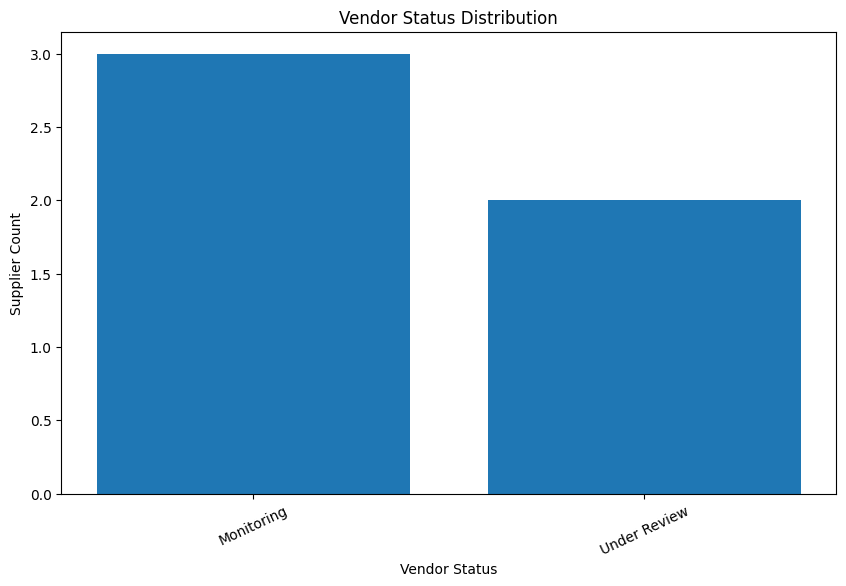

In [25]:
#visual
status_counts = (
    vendor_risk_register["vendor_status"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Vendor Status Distribution")
plt.xlabel("Vendor Status")
plt.ylabel("Supplier Count")

plt.xticks(rotation=25)

plt.show()

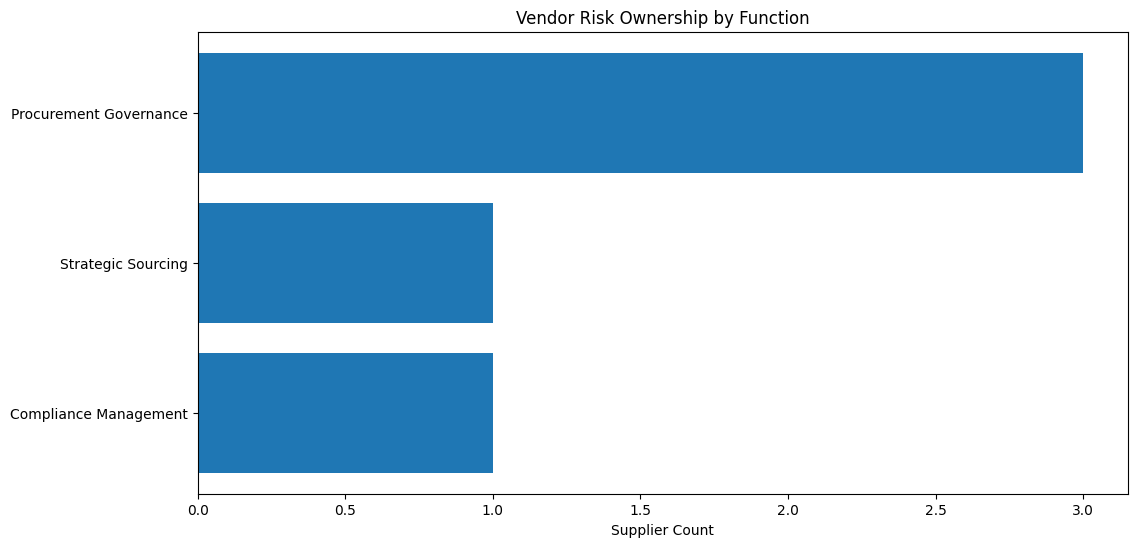

In [26]:
#owner workload
owner_counts = (
    vendor_risk_register["risk_owner"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 6))

plt.barh(
    owner_counts.index,
    owner_counts.values
)

plt.title("Vendor Risk Ownership by Function")
plt.xlabel("Supplier Count")

plt.show()

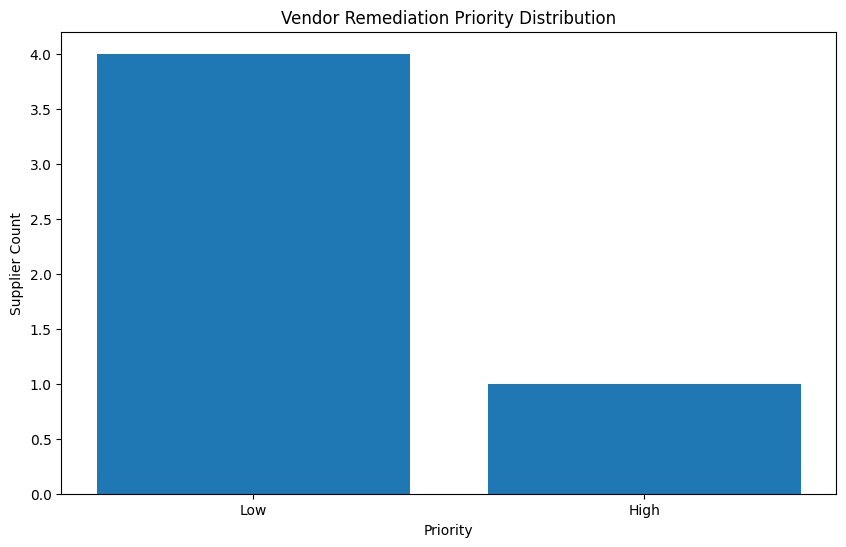

In [27]:
#remediation priority dist
priority_counts = (
    vendor_risk_register["remediation_priority"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    priority_counts.index,
    priority_counts.values
)

plt.title("Vendor Remediation Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Supplier Count")

plt.show()

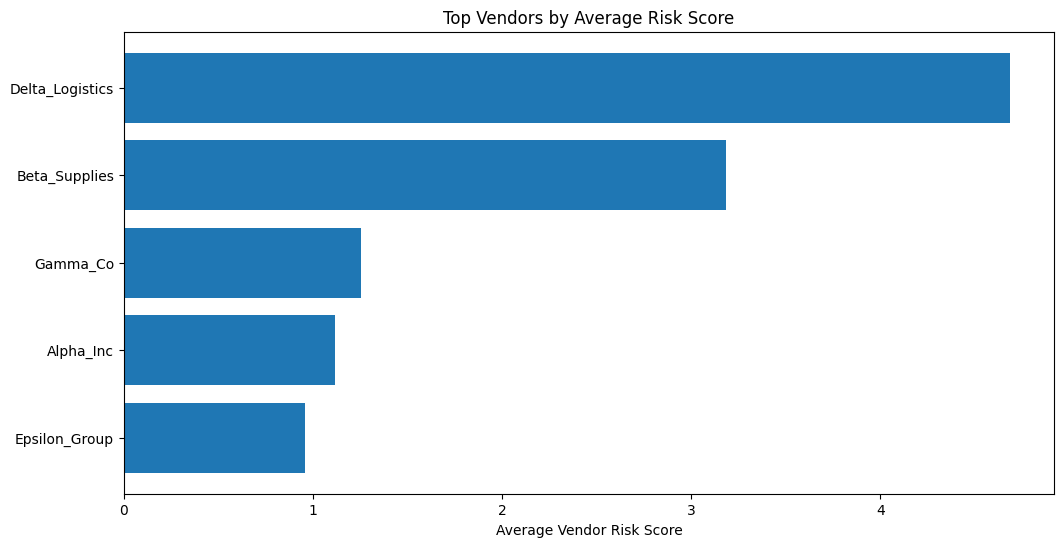

In [28]:
#vendors by risk score
top_vendor_risk = (
    vendor_risk_register
    .sort_values("avg_vendor_risk_score", ascending=True)
    .tail(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_vendor_risk["supplier"],
    top_vendor_risk["avg_vendor_risk_score"]
)

plt.title("Top Vendors by Average Risk Score")
plt.xlabel("Average Vendor Risk Score")

plt.show()

## Vendor Risk Register and Remediation Tracking

A vendor risk register was created to simulate enterprise third-party risk management and procurement governance.

Each supplier was assigned a risk owner, vendor status, remediation priority, recommended remediation action, review due date, and overdue review flag based on supplier performance indicators.

The risk register uses supplier-level metrics such as late delivery rate, defect rate, compliance failure rate, cancelled order rate, total spend, and average vendor risk score to determine ownership and remediation requirements.

Suppliers with elevated risk levels are routed to appropriate governance functions such as Compliance Management, Supplier Quality, Procurement Operations, Vendor Management, Strategic Sourcing, or Procurement Governance.

The vendor risk register supports:

- third-party risk oversight
- supplier performance governance
- compliance monitoring
- remediation tracking
- vendor accountability
- procurement risk management
- audit readiness
- executive reporting

---

In [29]:
##Vendor risk matrix

#impact score
def vendor_impact_score(row):

    if row["total_spend"] >= supplier_summary["total_spend"].quantile(0.90):
        return 4

    elif row["total_spend"] >= supplier_summary["total_spend"].quantile(0.75):
        return 3

    elif row["total_spend"] >= supplier_summary["total_spend"].quantile(0.50):
        return 2

    else:
        return 1


supplier_summary["impact_score"] = (
    supplier_summary.apply(vendor_impact_score, axis=1)
)

#likelihood score
def vendor_likelihood_score(row):

    score = 1

    if row["late_delivery_rate"] > supplier_summary["late_delivery_rate"].quantile(0.75):
        score += 1

    if row["avg_defect_rate"] > supplier_summary["avg_defect_rate"].quantile(0.75):
        score += 1

    if row["compliance_failure_rate"] > supplier_summary["compliance_failure_rate"].quantile(0.75):
        score += 1

    if row["cancelled_order_rate"] > supplier_summary["cancelled_order_rate"].quantile(0.75):
        score += 1

    return min(score, 4)


supplier_summary["likelihood_score"] = (
    supplier_summary.apply(vendor_likelihood_score, axis=1)
)

In [30]:
#vendor matrix score
supplier_summary["vendor_matrix_score"] = (
    supplier_summary["impact_score"] *
    supplier_summary["likelihood_score"]
)

#classify risk
def vendor_matrix_level(score):

    if score <= 3:
        return "Low"

    elif score <= 6:
        return "Medium"

    elif score <= 9:
        return "High"

    else:
        return "Critical"


supplier_summary["vendor_matrix_level"] = (
    supplier_summary["vendor_matrix_score"]
    .apply(vendor_matrix_level)
)

#review results
supplier_summary[[
    "supplier",
    "total_spend",
    "late_delivery_rate",
    "avg_defect_rate",
    "compliance_failure_rate",
    "cancelled_order_rate",
    "impact_score",
    "likelihood_score",
    "vendor_matrix_score",
    "vendor_matrix_level"
]].sort_values(
    "vendor_matrix_score",
    ascending=False
).head(10)

,supplier,total_spend,late_delivery_rate,avg_defect_rate,compliance_failure_rate,cancelled_order_rate,impact_score,likelihood_score,vendor_matrix_score,vendor_matrix_level
2,Delta_Logistics,9236240.47,21.052632,10.866574,39.181287,9.356725,2,4,8,High
1,Beta_Supplies,9858665.90,19.230769,8.272327,24.358974,8.974359,4,1,4,Medium
3,Epsilon_Group,9851156.06,19.277108,2.606269,1.807229,8.433735,3,1,3,Low
0,Alpha_Inc,7839712.25,14.893617,1.890548,6.382979,9.219858,1,1,1,Low
4,Gamma_Co,8587921.71,14.685315,4.497537,13.986014,4.195804,1,1,1,Low


In [31]:
##Matrix table
vendor_risk_matrix = pd.crosstab(
    supplier_summary["impact_score"],
    supplier_summary["likelihood_score"]
)

vendor_risk_matrix = vendor_risk_matrix.reindex(
    index=[1, 2, 3, 4],
    columns=[1, 2, 3, 4],
    fill_value=0
)

vendor_risk_matrix

likelihood_score,1,2,3,4
impact_score,,,,
1,2,0,0,0
2,0,0,0,1
3,1,0,0,0
4,1,0,0,0


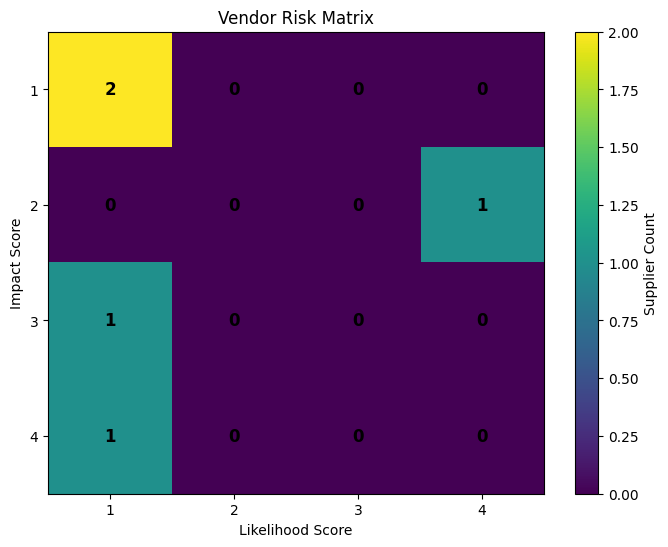

In [33]:
from pathlib import Path

Path("outputs/charts").mkdir(
    parents=True,
    exist_ok=True
)

plt.figure(figsize=(8, 6))

matrix_plot = plt.imshow(
    vendor_risk_matrix,
    aspect="auto"
)

plt.colorbar(
    matrix_plot,
    label="Supplier Count"
)

for i in range(vendor_risk_matrix.shape[0]):
    for j in range(vendor_risk_matrix.shape[1]):
        plt.text(
            j,
            i,
            int(vendor_risk_matrix.iloc[i, j]),
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold"
        )

plt.xticks(
    ticks=range(4),
    labels=["1", "2", "3", "4"]
)

plt.yticks(
    ticks=range(4),
    labels=["1", "2", "3", "4"]
)

plt.xlabel("Likelihood Score")
plt.ylabel("Impact Score")
plt.title("Vendor Risk Matrix")

plt.savefig(
    "outputs/charts/vendor_risk_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
##Critical register
critical_vendor_matrix_register = supplier_summary[
    supplier_summary["vendor_matrix_level"] == "Critical"
].copy()

critical_vendor_matrix_register = critical_vendor_matrix_register[[
    "supplier",
    "total_orders",
    "total_spend",
    "avg_delivery_days",
    "late_delivery_rate",
    "avg_defect_rate",
    "compliance_failure_rate",
    "cancelled_order_rate",
    "avg_cost_savings_rate",
    "avg_vendor_risk_score",
    "supplier_risk_level",
    "impact_score",
    "likelihood_score",
    "vendor_matrix_score",
    "vendor_matrix_level",
    "risk_owner",
    "vendor_status",
    "remediation_priority",
    "remediation_action",
    "review_due_date",
    "review_overdue_flag"
]]

critical_vendor_matrix_register.head()

#save
Path("outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

critical_vendor_matrix_register.to_csv(
    "outputs/tables/critical_vendor_matrix_register.csv",
    index=False
)

print("Critical vendor matrix register saved successfully.")

Critical vendor matrix register saved successfully.


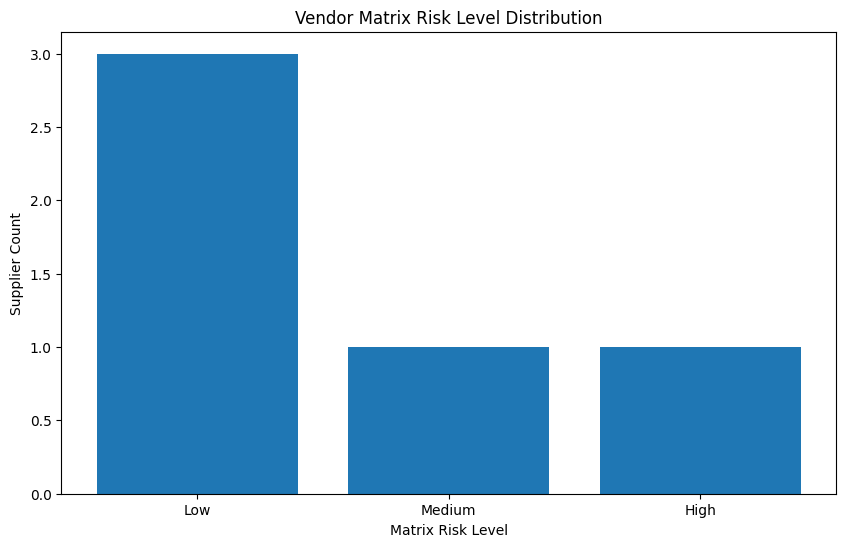

In [36]:
##Matrix level dist
matrix_level_counts = (
    supplier_summary["vendor_matrix_level"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    matrix_level_counts.index,
    matrix_level_counts.values
)

plt.title("Vendor Matrix Risk Level Distribution")
plt.xlabel("Matrix Risk Level")
plt.ylabel("Supplier Count")

plt.show()

In [38]:
#summary
vendor_matrix_summary = (
    supplier_summary
    .groupby("vendor_matrix_level")
    .agg(
        supplier_count=("supplier", "count"),
        total_spend=("total_spend", "sum"),
        avg_late_delivery_rate=("late_delivery_rate", "mean"),
        avg_defect_rate=("avg_defect_rate", "mean"),
        avg_compliance_failure_rate=("compliance_failure_rate", "mean"),
        avg_cancelled_order_rate=("cancelled_order_rate", "mean"),
        avg_vendor_risk_score=("avg_vendor_risk_score", "mean")
    )
    .reset_index()
)

vendor_matrix_summary

vendor_matrix_summary.to_csv(
    "outputs/tables/vendor_matrix_summary.csv",
    index=False
)

print("Vendor matrix summary saved successfully.")

Vendor matrix summary saved successfully.


## Vendor Risk Matrix

A vendor risk matrix was created to evaluate suppliers using an impact and likelihood framework.

Impact was based on supplier spend concentration. Suppliers with higher total spend were assigned higher impact scores because failures from these vendors may create greater financial, operational, or procurement disruption.

Likelihood was based on recurring supplier risk indicators, including late delivery rate, defect rate, compliance failure rate, and cancelled order rate. Suppliers with multiple elevated risk indicators were assigned higher likelihood scores.

The vendor matrix score was calculated as:

Impact Score × Likelihood Score = Vendor Matrix Score

Suppliers were then classified into Low, Medium, High, or Critical matrix risk levels.

This matrix supports:
- supplier risk prioritization
- third-party risk oversight
- procurement governance
- supplier remediation planning
- vendor concentration analysis
- audit readiness
- executive reporting

---

### Vendor Risk Matrix Finding

The vendor risk matrix identified suppliers with elevated impact and likelihood profiles. High-impact suppliers represent greater operational exposure due to larger spend concentration, while high-likelihood suppliers demonstrated recurring risk indicators such as late delivery, defects, compliance failures, or cancelled orders.

Suppliers classified as High or Critical should receive enhanced monitoring, remediation plans, and periodic vendor risk review.

---

In [39]:
##======DASHBOARD======##

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

Path("outputs/charts").mkdir(
    parents=True,
    exist_ok=True
)

#kpi calcs
total_pos = len(df)

total_suppliers = df["supplier"].nunique()

total_spend = round(
    df["negotiated_order_value"].sum(),
    2
)

avg_delivery_days = round(
    df["delivery_days"].mean(),
    2
)

late_orders = int(
    df["late_delivery_flag"].sum()
)

compliance_failures = int(
    df["compliance_failure_flag"].sum()
)

high_risk_vendors = len(
    vendor_risk_register[
        vendor_risk_register["supplier_risk_level"] == "High"
    ]
)

critical_matrix_vendors = len(
    supplier_summary[
        supplier_summary["vendor_matrix_level"] == "Critical"
    ]
)

overdue_vendor_reviews = int(
    vendor_risk_register["review_overdue_flag"].sum()
)

In [40]:
#helper funcs
def format_number(value):
    value = float(value)

    if abs(value) >= 1_000_000_000:
        return f"{value / 1_000_000_000:.1f}B"
    elif abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    elif abs(value) >= 1_000:
        return f"{value / 1_000:.1f}K"
    else:
        return f"{value:,.0f}"


def format_currency(value):
    value = float(value)

    if abs(value) >= 1_000_000_000:
        return f"${value / 1_000_000_000:.1f}B"
    elif abs(value) >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"
    elif abs(value) >= 1_000:
        return f"${value / 1_000:.1f}K"
    else:
        return f"${value:,.0f}"


def shorten_text(text, max_len=22):
    text = str(text).strip()
    return text if len(text) <= max_len else text[:max_len] + "..."


def create_kpi_card(ax, title, value, subtitle=None):
    ax.axis("off")

    rect = plt.Rectangle(
        (0, 0),
        1,
        1,
        fill=False,
        linewidth=1.4,
        transform=ax.transAxes
    )

    ax.add_patch(rect)

    ax.text(
        0.5,
        0.62,
        str(value),
        ha="center",
        va="center",
        fontsize=21,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.30,
        title,
        ha="center",
        va="center",
        fontsize=9,
        wrap=True
    )

    if subtitle:
        ax.text(
            0.5,
            0.12,
            subtitle,
            ha="center",
            va="center",
            fontsize=8
        )

In [41]:
#chart data
risk_counts = (
    vendor_risk_register["supplier_risk_level"]
    .value_counts()
)

vendor_status_counts = (
    vendor_risk_register["vendor_status"]
    .value_counts()
    .sort_values(ascending=True)
)

owner_counts = (
    vendor_risk_register["risk_owner"]
    .value_counts()
    .sort_values(ascending=True)
)

priority_counts = (
    vendor_risk_register["remediation_priority"]
    .value_counts()
)

matrix_level_counts = (
    supplier_summary["vendor_matrix_level"]
    .value_counts()
)

top_vendor_risk = (
    vendor_risk_register
    .sort_values("avg_vendor_risk_score", ascending=True)
    .tail(8)
    .copy()
)

top_vendor_risk["supplier_short"] = (
    top_vendor_risk["supplier"]
    .apply(lambda x: shorten_text(x, 24))
)

compliance_by_supplier = (
    vendor_risk_register
    .sort_values("compliance_failure_rate", ascending=True)
    .tail(8)
    .copy()
)

compliance_by_supplier["supplier_short"] = (
    compliance_by_supplier["supplier"]
    .apply(lambda x: shorten_text(x, 24))
)

failed_control_chart = (
    control_summary_df
    .sort_values("Failed", ascending=True)
    .copy()
)

failed_control_chart["Short Control"] = (
    failed_control_chart["Control"]
    .str.replace("CTRL-001 ", "", regex=False)
    .str.replace("CTRL-002 ", "", regex=False)
    .str.replace("CTRL-003 ", "", regex=False)
    .str.replace("CTRL-004 ", "", regex=False)
    .str.replace("CTRL-005 ", "", regex=False)
    .str.replace("CTRL-006 ", "", regex=False)
    .replace({
        "Order and Delivery Dates Present": "Order/Delivery Dates",
        "Valid Delivery Timeline": "Valid Timeline",
        "Compliance Status Present": "Compliance Present",
        "Price Fields Present": "Prices Present",
        "Positive Quantity": "Positive Qty",
        "Supplier Present": "Supplier Present"
    })
)

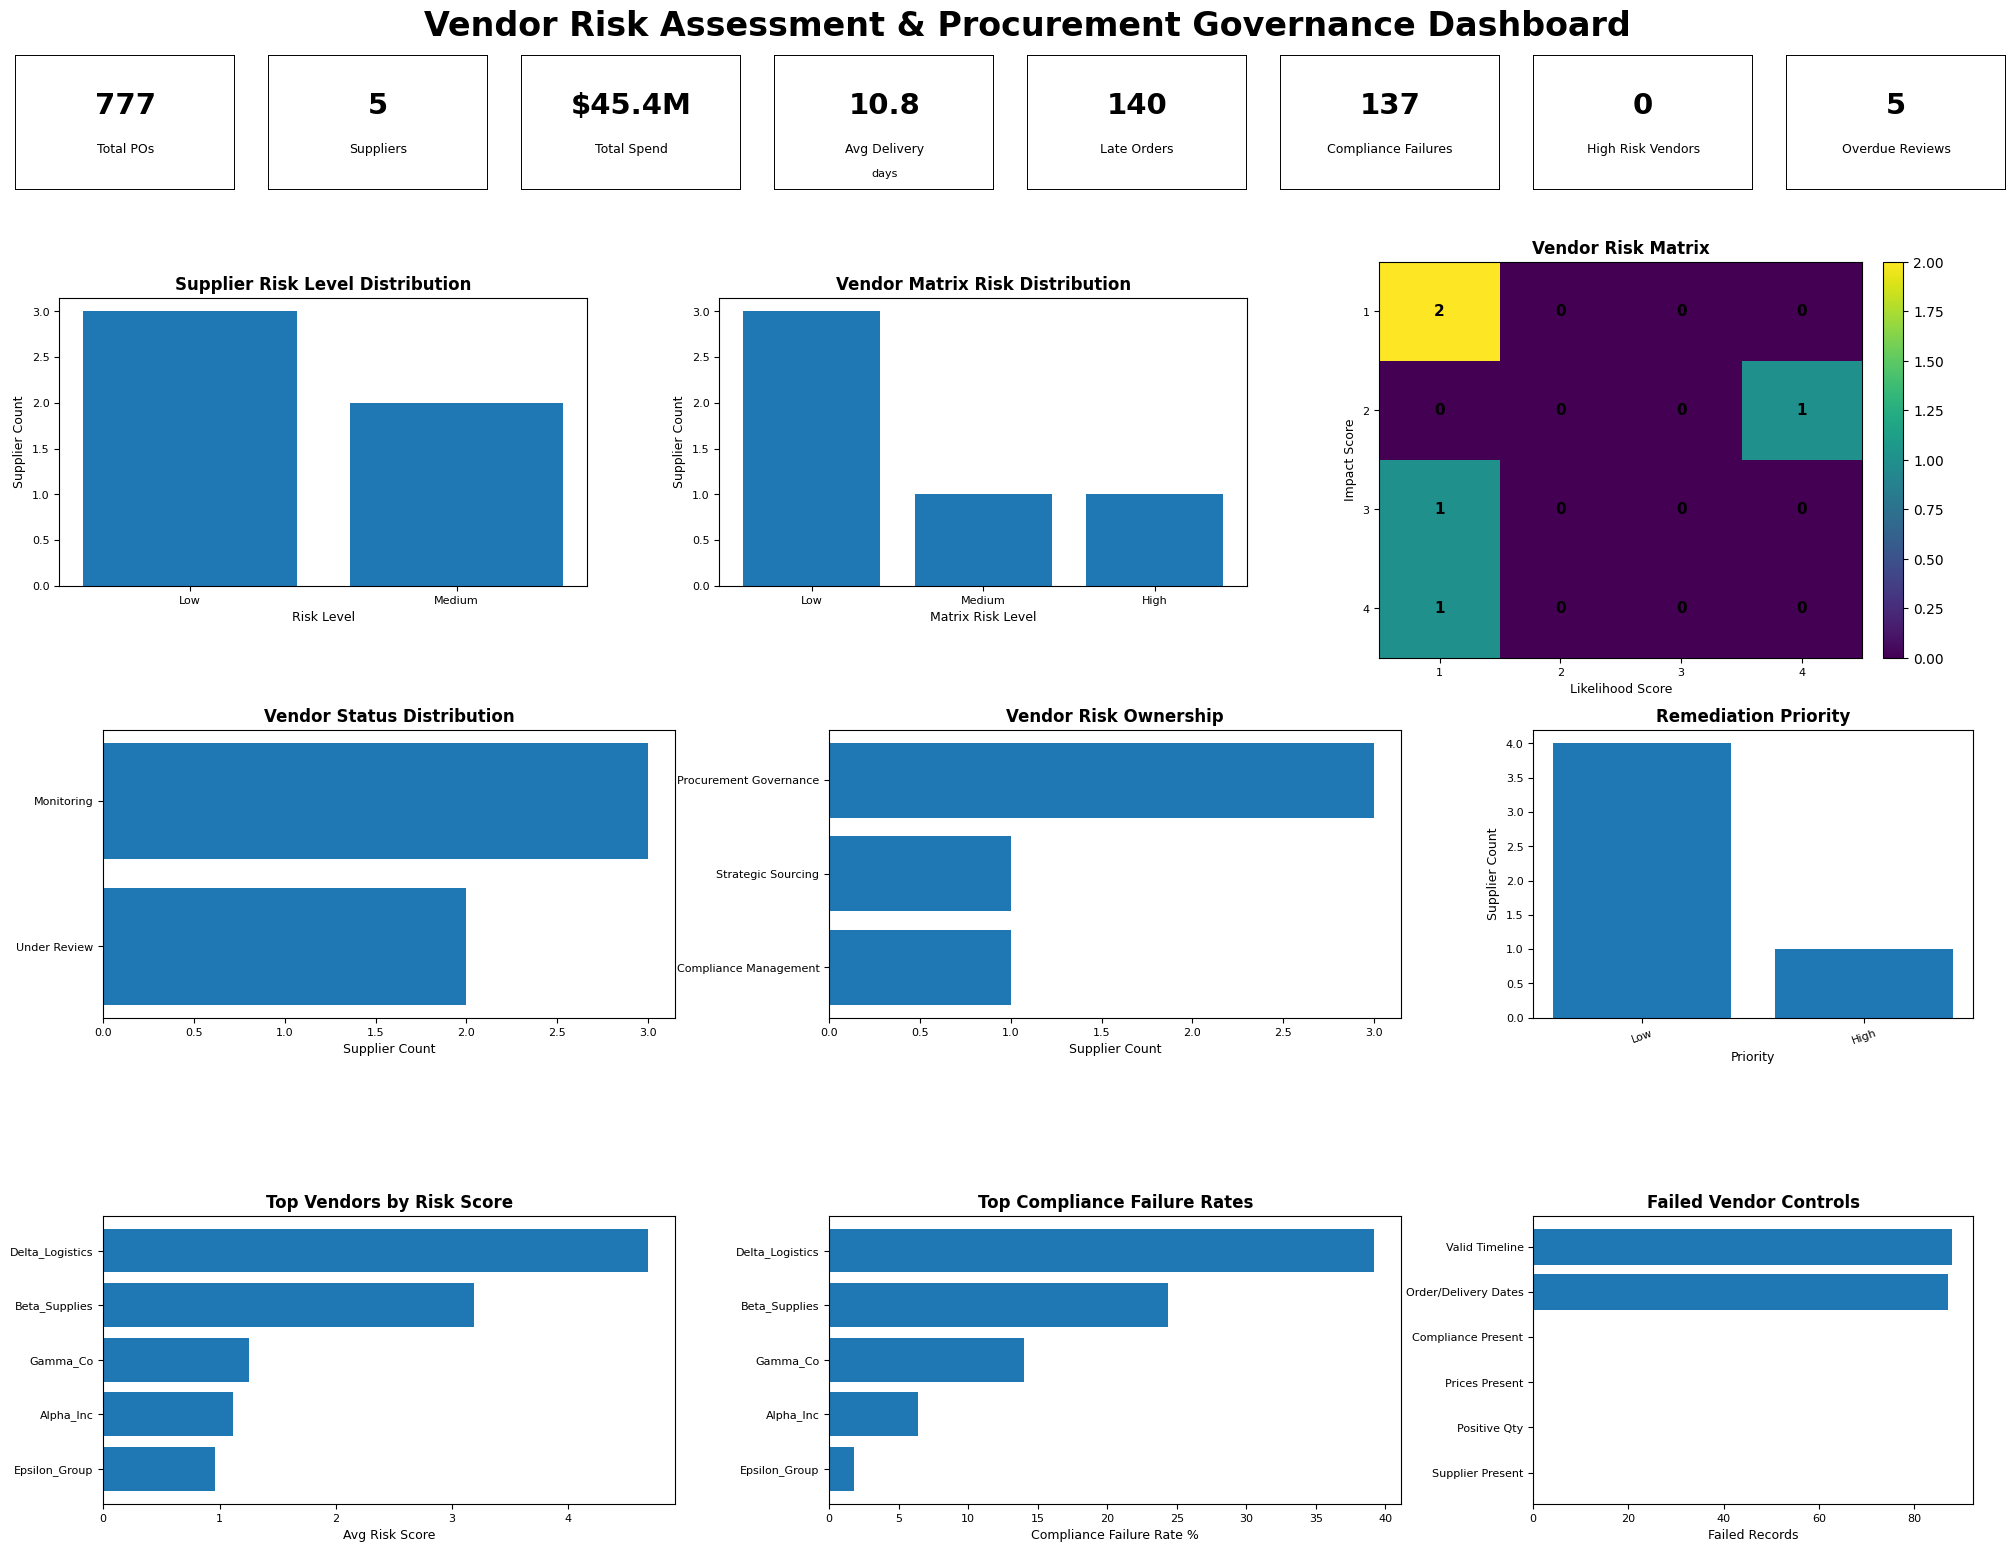

In [42]:
#dash
fig = plt.figure(figsize=(22, 18))

fig.suptitle(
    "Vendor Risk Assessment & Procurement Governance Dashboard",
    fontsize=24,
    fontweight="bold",
    y=0.98
)

# =========================
# KPI CARDS
# =========================

kpi_positions = [
    [0.04, 0.88, 0.10, 0.075],
    [0.155, 0.88, 0.10, 0.075],
    [0.27, 0.88, 0.10, 0.075],
    [0.385, 0.88, 0.10, 0.075],
    [0.50, 0.88, 0.10, 0.075],
    [0.615, 0.88, 0.10, 0.075],
    [0.73, 0.88, 0.10, 0.075],
    [0.845, 0.88, 0.10, 0.075]
]

kpi_values = [
    ("Total POs", format_number(total_pos), None),
    ("Suppliers", format_number(total_suppliers), None),
    ("Total Spend", format_currency(total_spend), None),
    ("Avg Delivery", f"{avg_delivery_days:.1f}", "days"),
    ("Late Orders", format_number(late_orders), None),
    ("Compliance Failures", format_number(compliance_failures), None),
    ("High Risk Vendors", format_number(high_risk_vendors), None),
    ("Overdue Reviews", format_number(overdue_vendor_reviews), None)
]

for pos, item in zip(kpi_positions, kpi_values):
    ax = fig.add_axes(pos)
    create_kpi_card(
        ax,
        item[0],
        item[1],
        item[2]
    )

# =========================
# ROW 1: RISK DISTRIBUTIONS
# =========================

ax1 = fig.add_axes([0.06, 0.66, 0.24, 0.16])

ax1.bar(
    risk_counts.index,
    risk_counts.values
)

ax1.set_title("Supplier Risk Level Distribution", fontsize=12, fontweight="bold")
ax1.set_xlabel("Risk Level", fontsize=9)
ax1.set_ylabel("Supplier Count", fontsize=9)
ax1.tick_params(labelsize=8)


ax2 = fig.add_axes([0.36, 0.66, 0.24, 0.16])

ax2.bar(
    matrix_level_counts.index,
    matrix_level_counts.values
)

ax2.set_title("Vendor Matrix Risk Distribution", fontsize=12, fontweight="bold")
ax2.set_xlabel("Matrix Risk Level", fontsize=9)
ax2.set_ylabel("Supplier Count", fontsize=9)
ax2.tick_params(labelsize=8)


ax3 = fig.add_axes([0.66, 0.62, 0.24, 0.22])

matrix_plot = ax3.imshow(
    vendor_risk_matrix,
    aspect="auto"
)

for i in range(vendor_risk_matrix.shape[0]):
    for j in range(vendor_risk_matrix.shape[1]):
        value = int(vendor_risk_matrix.iloc[i, j])
        ax3.text(
            j,
            i,
            value,
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

ax3.set_xticks(range(4))
ax3.set_xticklabels(["1", "2", "3", "4"])
ax3.set_yticks(range(4))
ax3.set_yticklabels(["1", "2", "3", "4"])
ax3.set_xlabel("Likelihood Score", fontsize=9)
ax3.set_ylabel("Impact Score", fontsize=9)
ax3.set_title("Vendor Risk Matrix", fontsize=12, fontweight="bold")
ax3.tick_params(labelsize=8)

fig.colorbar(
    matrix_plot,
    ax=ax3,
    fraction=0.045,
    pad=0.04
)

# =========================
# ROW 2: STATUS / OWNER / PRIORITY
# =========================

ax4 = fig.add_axes([0.08, 0.42, 0.26, 0.16])

ax4.barh(
    vendor_status_counts.index,
    vendor_status_counts.values
)

ax4.set_title("Vendor Status Distribution", fontsize=12, fontweight="bold")
ax4.set_xlabel("Supplier Count", fontsize=9)
ax4.tick_params(axis="y", labelsize=8)
ax4.tick_params(axis="x", labelsize=8)


ax5 = fig.add_axes([0.41, 0.42, 0.26, 0.16])

ax5.barh(
    owner_counts.index,
    owner_counts.values
)

ax5.set_title("Vendor Risk Ownership", fontsize=12, fontweight="bold")
ax5.set_xlabel("Supplier Count", fontsize=9)
ax5.tick_params(axis="y", labelsize=8)
ax5.tick_params(axis="x", labelsize=8)


ax6 = fig.add_axes([0.73, 0.42, 0.20, 0.16])

ax6.bar(
    priority_counts.index,
    priority_counts.values
)

ax6.set_title("Remediation Priority", fontsize=12, fontweight="bold")
ax6.set_xlabel("Priority", fontsize=9)
ax6.set_ylabel("Supplier Count", fontsize=9)
ax6.tick_params(axis="x", rotation=20, labelsize=8)
ax6.tick_params(axis="y", labelsize=8)

# =========================
# ROW 3: SUPPLIER RANKINGS / CONTROLS
# =========================

ax7 = fig.add_axes([0.08, 0.15, 0.26, 0.16])

ax7.barh(
    top_vendor_risk["supplier_short"],
    top_vendor_risk["avg_vendor_risk_score"]
)

ax7.set_title("Top Vendors by Risk Score", fontsize=12, fontweight="bold")
ax7.set_xlabel("Avg Risk Score", fontsize=9)
ax7.tick_params(axis="y", labelsize=8)
ax7.tick_params(axis="x", labelsize=8)


ax8 = fig.add_axes([0.41, 0.15, 0.26, 0.16])

ax8.barh(
    compliance_by_supplier["supplier_short"],
    compliance_by_supplier["compliance_failure_rate"]
)

ax8.set_title("Top Compliance Failure Rates", fontsize=12, fontweight="bold")
ax8.set_xlabel("Compliance Failure Rate %", fontsize=9)
ax8.tick_params(axis="y", labelsize=8)
ax8.tick_params(axis="x", labelsize=8)


ax9 = fig.add_axes([0.73, 0.15, 0.20, 0.16])

ax9.barh(
    failed_control_chart["Short Control"],
    failed_control_chart["Failed"]
)

ax9.set_title("Failed Vendor Controls", fontsize=12, fontweight="bold")
ax9.set_xlabel("Failed Records", fontsize=9)
ax9.tick_params(axis="y", labelsize=8)
ax9.tick_params(axis="x", labelsize=8)

# =========================
# SAVE AND SHOW
# =========================

plt.savefig(
    "outputs/charts/vendor_risk_governance_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Executive Vendor Risk Dashboard

The Vendor Risk Assessment & Procurement Governance Dashboard provides an executive-level view of supplier performance, third-party risk exposure, remediation status, and procurement control effectiveness.

The dashboard consolidates key vendor governance indicators including total purchase orders, supplier count, total spend, average delivery time, late orders, compliance failures, high-risk vendors, and overdue vendor reviews.

The supplier risk distribution and vendor risk matrix summarize vendor exposure using both risk score classifications and an impact-likelihood framework. Suppliers with high impact and high likelihood scores represent elevated third-party risk requiring enhanced monitoring and remediation.

The vendor status, risk ownership, and remediation priority visuals simulate an enterprise third-party risk workflow by showing which suppliers require monitoring, remediation, escalation, or ownership assignment.

The supplier ranking charts identify vendors with the highest average risk scores and highest compliance failure rates. The failed control chart summarizes procurement governance control failures across supplier, date, quantity, price, compliance, and delivery timeline controls.

Overall, this dashboard supports supplier oversight, procurement governance, third-party risk management, compliance monitoring, remediation prioritization, and audit readiness.

---